In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (2).png
/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (285).png
/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (166)_mask.png
/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (290)_mask.png
/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (300).png
/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (390).png
/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (357).png
/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (430)_mask.png
/kaggle/input/datasets/subhajournal

In [2]:
!pip install torch torchvision scikit-learn seaborn

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from PIL import Image

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [11]:
data_path = "/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

classes = ["benign","malignant","normal"]

paths = []
labels = []

for cls in classes:
    
    folder = os.path.join(data_path,cls)
    
    for img in os.listdir(folder):
        
        if "_mask" not in img:
            
            paths.append(os.path.join(folder,img))
            labels.append(cls)

data = pd.DataFrame({
    "path":paths,
    "label":labels
})

print(data.label.value_counts())

label
benign       437
malignant    210
normal       133
Name: count, dtype: int64


In [12]:
label_dict = {"benign":0,"malignant":1,"normal":2}
data["label"] = data["label"].map(label_dict)

In [14]:
train_df, temp_df = train_test_split(
    data,
    test_size=0.30,
    stratify=data["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 546
Validation size: 117
Test size: 117


In [15]:
basic_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [16]:
aug_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224,scale=(0.8,1.0)),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor()
])

In [17]:
class BUSIDataset(Dataset):
    
    def __init__(self,df,transform):
        self.df = df
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self,index):
        
        img_path = self.df.iloc[index]["path"]
        label = self.df.iloc[index]["label"]
        
        img = Image.open(img_path).convert("RGB")
        
        img = self.transform(img)
        
        return img,label

In [18]:
train_dataset = BUSIDataset(train_df,basic_transform)
val_dataset = BUSIDataset(val_df,basic_transform)
test_dataset = BUSIDataset(test_df,basic_transform)

train_dataset_aug = BUSIDataset(train_df,aug_transform)

In [19]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

In [20]:
val_loader = DataLoader(val_dataset,batch_size=32)
test_loader = DataLoader(test_dataset,batch_size=32)

In [24]:
def build_model():
    
    model = models.resnet18(pretrained=True)
    
    model.fc = nn.Linear(model.fc.in_features,3)
    
    return model.to(device)

In [25]:
def train_model(model,train_loader,val_loader,criterion,optimizer,epochs=10):
    
    for epoch in range(epochs):
        
        model.train()
        
        train_loss = 0
        
        for x,y in train_loader:
            
            x,y = x.to(device),y.to(device)
            
            optimizer.zero_grad()
            
            out = model(x)
            
            loss = criterion(out,y)
            
            loss.backward()
            
            optimizer.step()
            
            train_loss += loss.item()
        
        
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            
            for x,y in val_loader:
                
                x,y = x.to(device),y.to(device)
                
                out = model(x)
                
                loss = criterion(out,y)
                
                val_loss += loss.item()
        
        
        print(f"Epoch {epoch+1} Train {train_loss/len(train_loader):.4f} Val {val_loss/len(val_loader):.4f}")

In [26]:
def evaluate(model):
    
    model.eval()
    
    preds = []
    true = []
    
    with torch.no_grad():
        
        for x,y in test_loader:
            
            x = x.to(device)
            
            out = model(x)
            
            _,p = torch.max(out,1)
            
            preds.extend(p.cpu().numpy())
            true.extend(y.numpy())
    
    
    print(classification_report(true,preds))
    
    cm = confusion_matrix(true,preds)
    
    plt.figure(figsize=(6,6))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
    plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


Epoch 1 Train 0.8984 Val 0.9861
Epoch 2 Train 0.2391 Val 0.7553
Epoch 3 Train 0.1208 Val 0.4367
Epoch 4 Train 0.0734 Val 0.3884
Epoch 5 Train 0.0411 Val 0.3796
Epoch 6 Train 0.1248 Val 0.3664
Epoch 7 Train 0.0518 Val 0.3094
Epoch 8 Train 0.0746 Val 0.2372
Epoch 9 Train 0.0797 Val 0.3534
Epoch 10 Train 0.0878 Val 0.3277
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        66
           1       0.69      0.71      0.70        31
           2       0.81      0.65      0.72        20

    accuracy                           0.78       117
   macro avg       0.77      0.74      0.75       117
weighted avg       0.78      0.78      0.78       117



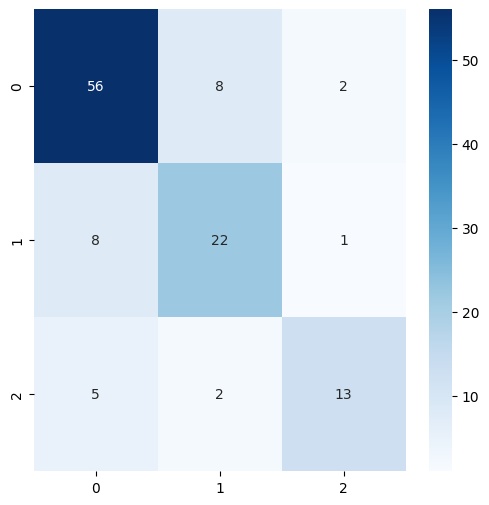

In [27]:
baseline_model = build_model()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(baseline_model.parameters(),lr=1e-4)

train_model(baseline_model,train_loader,val_loader,criterion,optimizer)

evaluate(baseline_model)

In [28]:
class_count = train_df["label"].value_counts().sort_index()

weights = 1./torch.tensor(class_count.values,dtype=torch.float)

sample_weights = weights[train_df["label"].values]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_over = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 Train 0.5810 Val 1.1177
Epoch 2 Train 0.1864 Val 0.7472
Epoch 3 Train 0.0986 Val 0.5266
Epoch 4 Train 0.0815 Val 0.3866
Epoch 5 Train 0.0599 Val 0.3906
Epoch 6 Train 0.2011 Val 0.3236
Epoch 7 Train 0.1098 Val 0.2681
Epoch 8 Train 0.0337 Val 0.2898
Epoch 9 Train 0.0456 Val 0.2748
Epoch 10 Train 0.0288 Val 0.3436
              precision    recall  f1-score   support

           0       0.76      0.88      0.82        66
           1       0.77      0.65      0.70        31
           2       0.87      0.65      0.74        20

    accuracy                           0.78       117
   macro avg       0.80      0.72      0.75       117
weighted avg       0.78      0.78      0.77       117



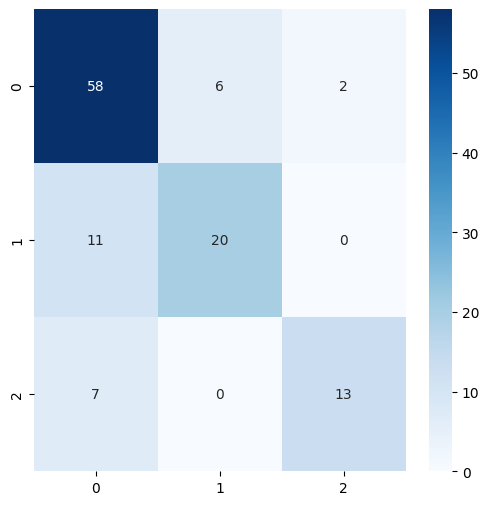

In [29]:
oversample_model = build_model()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(oversample_model.parameters(),lr=1e-4)

train_model(oversample_model,train_loader_over,val_loader,criterion,optimizer)

evaluate(oversample_model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 Train 0.8241 Val 0.8622
Epoch 2 Train 0.5258 Val 0.5382
Epoch 3 Train 0.4024 Val 0.4686
Epoch 4 Train 0.4536 Val 0.4228
Epoch 5 Train 0.2635 Val 0.4373
Epoch 6 Train 0.2335 Val 0.2849
Epoch 7 Train 0.3184 Val 0.3111
Epoch 8 Train 0.2249 Val 0.2597
Epoch 9 Train 0.2556 Val 0.3852
Epoch 10 Train 0.1433 Val 0.2564
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        66
           1       0.76      0.81      0.78        31
           2       0.78      0.70      0.74        20

    accuracy                           0.80       117
   macro avg       0.79      0.78      0.78       117
weighted avg       0.80      0.80      0.80       117



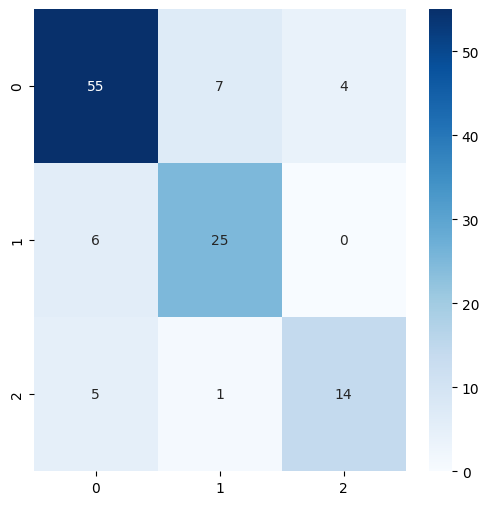

In [30]:
train_loader_aug = DataLoader(train_dataset_aug,batch_size=32,shuffle=True)

augment_model = build_model()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(augment_model.parameters(),lr=1e-4)

train_model(augment_model,train_loader_aug,val_loader,criterion,optimizer)

evaluate(augment_model)

In [31]:
class FocalLoss(nn.Module):
    
    def __init__(self,gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()
    
    def forward(self,inputs,targets):
        
        ce_loss = self.ce(inputs,targets)
        
        pt = torch.exp(-ce_loss)
        
        loss = (1-pt)**self.gamma * ce_loss
        
        return loss

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 Train 0.2417 Val 0.2706
Epoch 2 Train 0.0077 Val 0.0758
Epoch 3 Train 0.0717 Val 0.0548
Epoch 4 Train 0.0165 Val 0.0872
Epoch 5 Train 0.0058 Val 0.0471
Epoch 6 Train 0.0096 Val 0.0409
Epoch 7 Train 0.0014 Val 0.0407
Epoch 8 Train 0.0017 Val 0.0356
Epoch 9 Train 0.0039 Val 0.0334
Epoch 10 Train 0.0023 Val 0.0470
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        66
           1       0.67      0.77      0.72        31
           2       0.67      0.60      0.63        20

    accuracy                           0.74       117
   macro avg       0.71      0.72      0.71       117
weighted avg       0.75      0.74      0.74       117



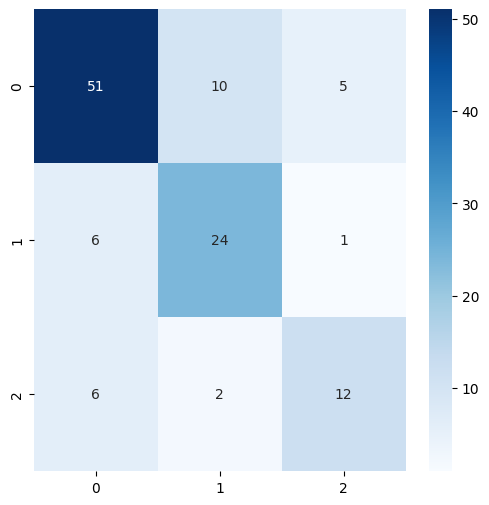

In [32]:
focal_model = build_model()

criterion = FocalLoss()

optimizer = optim.Adam(focal_model.parameters(),lr=1e-4)

train_model(focal_model,train_loader,val_loader,criterion,optimizer)

evaluate(focal_model)

In [33]:
results = {}

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_model(model, model_name):
    
    model.eval()
    
    preds = []
    true = []
    
    with torch.no_grad():
        
        for images,labels in test_loader:
            
            images = images.to(device)
            
            outputs = model(images)
            
            _,predicted = torch.max(outputs,1)
            
            preds.extend(predicted.cpu().numpy())
            true.extend(labels.numpy())
    
    
    acc = accuracy_score(true,preds)
    
    precision = precision_score(true,preds,average='macro')
    
    recall = recall_score(true,preds,average='macro')
    
    f1 = f1_score(true,preds,average='macro')
    
    
    results[model_name] = {
        "Accuracy":acc,
        "Precision":precision,
        "Recall":recall,
        "F1 Score":f1
    }
    
    
    print("\n",model_name)
    print(classification_report(true,preds))
    
    
    cm = confusion_matrix(true,preds)
    
    plt.figure(figsize=(6,6))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
    plt.title(model_name)
    plt.show()


 Baseline
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        66
           1       0.69      0.71      0.70        31
           2       0.81      0.65      0.72        20

    accuracy                           0.78       117
   macro avg       0.77      0.74      0.75       117
weighted avg       0.78      0.78      0.78       117



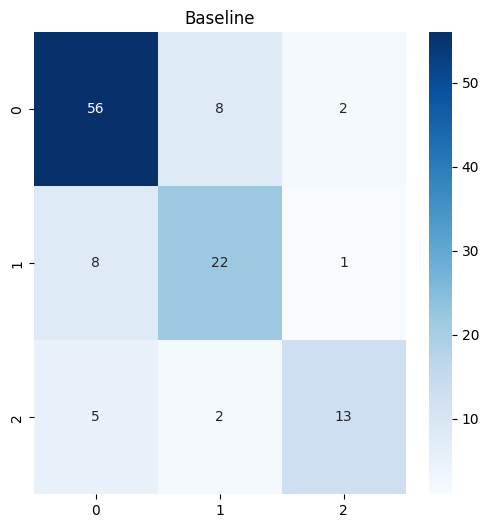

In [35]:
evaluate_model(baseline_model,"Baseline")


 Oversampling
              precision    recall  f1-score   support

           0       0.76      0.88      0.82        66
           1       0.77      0.65      0.70        31
           2       0.87      0.65      0.74        20

    accuracy                           0.78       117
   macro avg       0.80      0.72      0.75       117
weighted avg       0.78      0.78      0.77       117



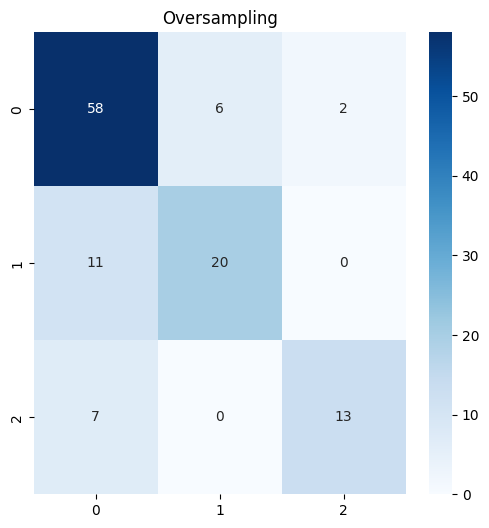

In [36]:
evaluate_model(oversample_model,"Oversampling")


 Augmentation
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        66
           1       0.76      0.81      0.78        31
           2       0.78      0.70      0.74        20

    accuracy                           0.80       117
   macro avg       0.79      0.78      0.78       117
weighted avg       0.80      0.80      0.80       117



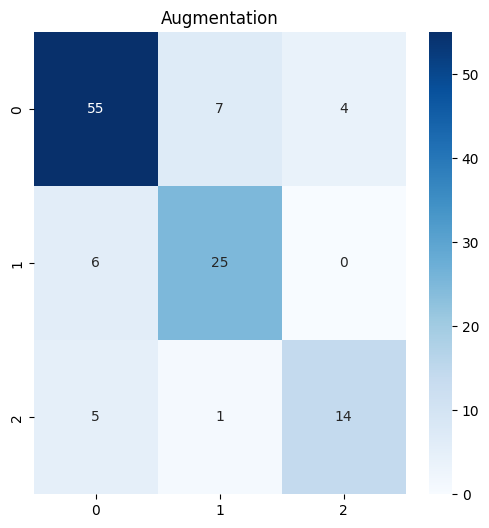

In [37]:
evaluate_model(augment_model,"Augmentation")


 Focal Loss
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        66
           1       0.67      0.77      0.72        31
           2       0.67      0.60      0.63        20

    accuracy                           0.74       117
   macro avg       0.71      0.72      0.71       117
weighted avg       0.75      0.74      0.74       117



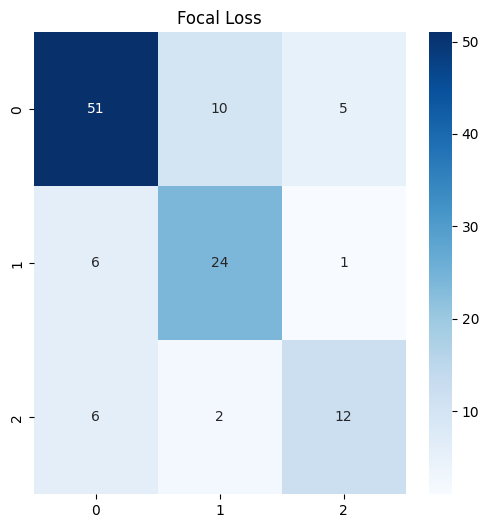

In [38]:
evaluate_model(focal_model,"Focal Loss")

In [39]:
comparison_df = pd.DataFrame(results).T

print("\nFinal Model Comparison\n")

print(comparison_df)


Final Model Comparison

              Accuracy  Precision    Recall  F1 Score
Baseline      0.777778   0.770531  0.736054  0.750088
Oversampling  0.777778   0.799685  0.724650  0.753838
Augmentation  0.803419   0.789562  0.779928  0.783808
Focal Loss    0.743590   0.714286  0.715640  0.712898
